In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load data (đảm bảo file data.csv đã nằm trong thư mục data)
df = pd.read_csv('../data/data.csv', encoding='latin1')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [3]:
df.dropna(subset=['CustomerID'], inplace=True)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.describe()

,Quantity,UnitPrice,CustomerID,TotalPrice
count,397884.000000,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,15294.423453,22.397000
std,179.331775,22.097877,1713.141560,309.071041
min,1.000000,0.001000,12346.000000,0.001000
25%,2.000000,1.250000,13969.000000,4.680000
50%,6.000000,1.950000,15159.000000,11.800000
75%,12.000000,3.750000,16795.000000,19.800000
max,80995.000000,8142.750000,18287.000000,168469.600000


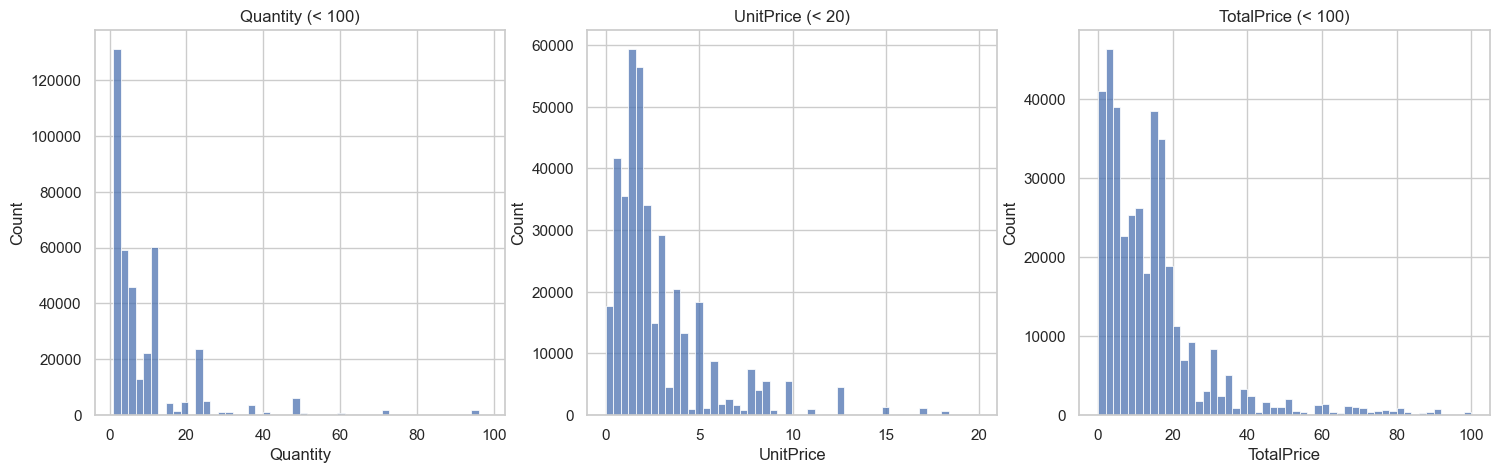

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Zoom in bằng cách chỉ vẽ dữ liệu của khách hàng phổ thông
sns.histplot(df[df['Quantity'] < 100]['Quantity'], bins=50, ax=axes[0]).set_title('Quantity (< 100)')
sns.histplot(df[df['UnitPrice'] < 20]['UnitPrice'], bins=50, ax=axes[1]).set_title('UnitPrice (< 20)')
sns.histplot(df[df['TotalPrice'] < 100]['TotalPrice'], bins=50, ax=axes[2]).set_title('TotalPrice (< 100)')

plt.show()

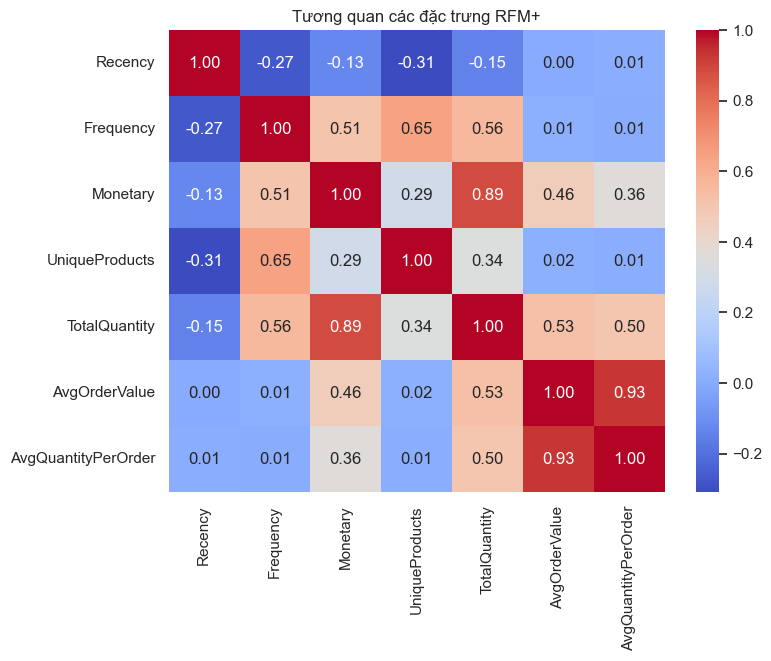

In [5]:
import sys
sys.path.append('../')
from src.preprocess import Preprocessor

prep = Preprocessor()
rfm_raw = prep.build_rfm_features(prep.load_and_clean(df))

plt.figure(figsize=(8, 6))
sns.heatmap(rfm_raw.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Tương quan các đặc trưng RFM+')
plt.show()